# 公式 o7 — Tyson1991（細胞周期の cdc2-cyclin 振動）

> **出典（E-Cell4 公式）**: Examples / example11 — https://ecell4.e-cell.org/examples/example11.html （Tyson 1991）
>
> 公式コードをそのまま移植（描画のみ matplotlib）。cdc2 と cyclin の相互作用による
> **M 期促進因子(MPF)の振動**——細胞周期エンジンの古典モデル。

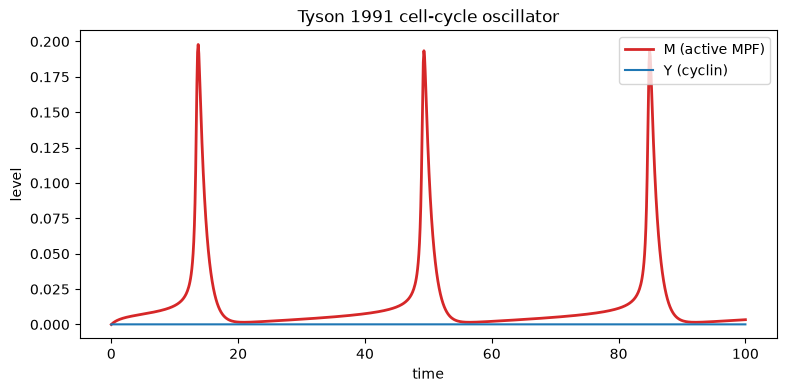

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

with reaction_rules():
    YT = Y + YP + M + pM
    CT = C2 + CP + M + pM
    ~Y > Y | 0.015 / CT
    Y > ~Y | 0.0 * Y
    CP + Y > pM | 200.0 * CP * Y / CT
    pM > M | pM * (0.018 + 180 * ((M / CT) ** 2))
    M > pM | 0.0 * M
    M > C2 + YP | 1.0 * M
    YP > ~YP | 0.6 * YP
    C2 > CP | 1000000.0 * C2
    CP > C2 | 1000.0 * CP
m = get_model()
a = run_simulation(100.0, ndiv=1000, model=m, y0={'CP': 0.75, 'pM': 0.25}, species_list=['M','pM','Y','YP','C2','CP']).as_array()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(a[:,0], a[:,1], 'C3', lw=2, label='M (active MPF)')
ax.plot(a[:,0], a[:,3], 'C0', label='Y (cyclin)')
ax.set_xlabel('time'); ax.set_ylabel('level'); ax.set_title('Tyson 1991 cell-cycle oscillator'); ax.legend()
plt.show()

## 読み取り

活性型 MPF (M) がスパイク状に振動する——細胞周期の M 期突入を繰り返すエンジン。cyclin (Y) の蓄積 → MPF 活性化 →
MPF が cyclin 分解を促す、という負フィードバックがリラクゼーション振動を生む。反応速度に分数式（`0.015/CT` など総量依存）を
書けるのが要点。